In [10]:
pip install pandas scikit-learn xgboost matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [11]:
from xgboost import XGBClassifier
print("XGBoost loaded successfully!")

XGBoost loaded successfully!


In [12]:
# !pip install pandas numpy matplotlib seaborn xgboost scikit-learn joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)

# Set visual style
sns.set_theme(style="whitegrid")

⚠️ Using synthetic data for structure demonstration.


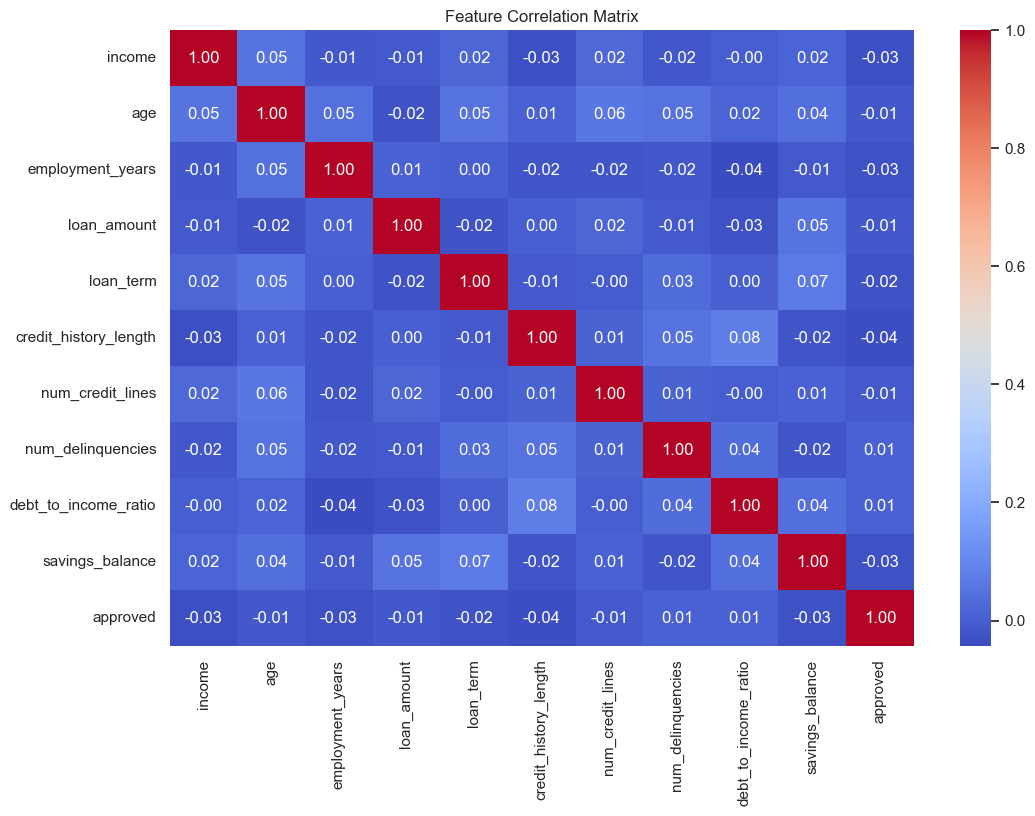

In [13]:
# Load Dataset
try:
    df = pd.read_csv('credit_data.csv')
    print("✅ Real dataset loaded.")
except FileNotFoundError:
    print("⚠️ Using synthetic data for structure demonstration.")
    # Create synthetic data with the 10 mandatory fields
    np.random.seed(42)
    data = {
        'income': np.random.normal(50000, 15000, 1000),
        'age': np.random.randint(18, 70, 1000),
        'employment_years': np.random.randint(0, 20, 1000),
        'loan_amount': np.random.normal(15000, 5000, 1000),
        'loan_term': np.random.choice([12, 24, 36, 48], 1000),
        'credit_history_length': np.random.randint(1, 25, 1000),
        'num_credit_lines': np.random.randint(1, 8, 1000),
        'num_delinquencies': np.random.randint(0, 3, 1000),
        'debt_to_income_ratio': np.random.uniform(0.1, 0.5, 1000),
        'savings_balance': np.random.normal(5000, 2000, 1000),
        'approved': np.random.choice([0, 1], 1000, p=[0.3, 0.7])
    }
    df = pd.DataFrame(data)

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [14]:
# Handle missing values if any
df = df.fillna(df.median())

# Define Features (X) and Target (y)
features = ['income', 'age', 'employment_years', 'loan_amount', 'loan_term', 
            'credit_history_length', 'num_credit_lines', 'num_delinquencies', 
            'debt_to_income_ratio', 'savings_balance']
X = df[features]
y = df['approved']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

/Users/queenceline/miniforge3/envs/tf_m4/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [21:46:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.29      0.10      0.15        60
           1       0.70      0.89      0.78       140

    accuracy                           0.66       200
   macro avg       0.49      0.50      0.47       200
weighted avg       0.57      0.66      0.59       200



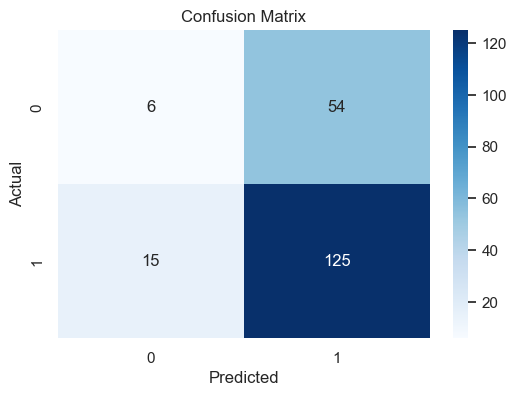

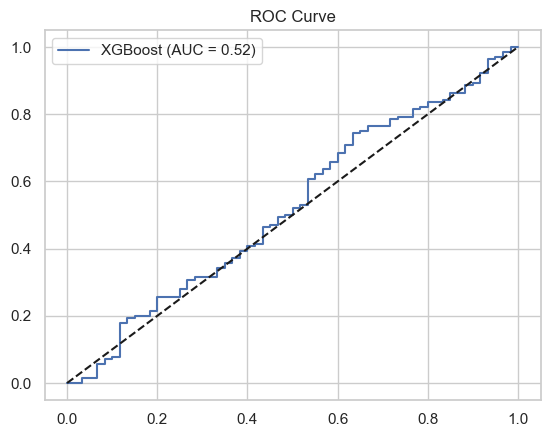

<Figure size 1000x600 with 0 Axes>

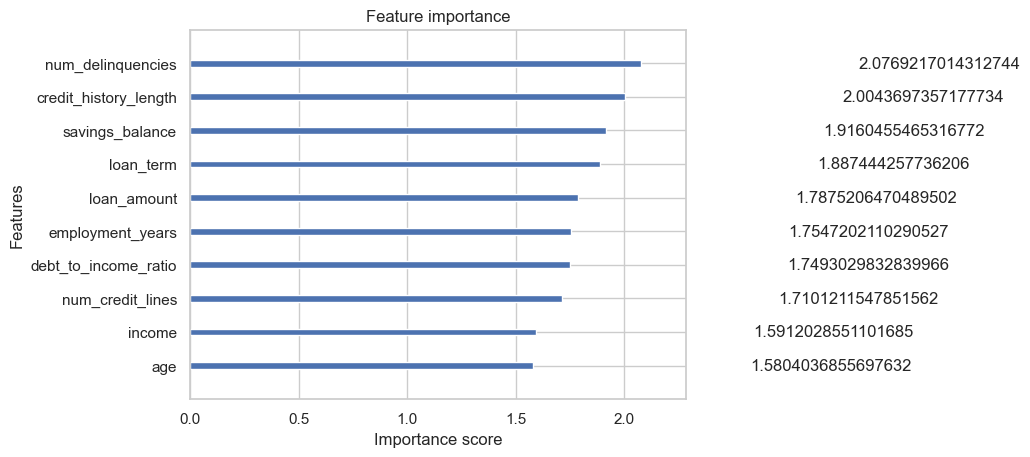

In [15]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 1. Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 4. Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='gain')
plt.show()

In [16]:
# Export the model
joblib.dump(model, 'credit_model.pkl')
print("✅ Phase 1 Complete: 'credit_model.pkl' is ready for Backend integration.")

✅ Phase 1 Complete: 'credit_model.pkl' is ready for Backend integration.


Phase 1: Xây dựng Mô hình Dự đoán Điểm tín dụng (the Brain)

1. Thiết lập môi trường
Cài đặt các thư viện cần thiết: pandas, scikit-learn, xgboost, và joblib.
Xử lý lỗi thư viện OpenMP (libomp) trên macOS để đảm bảo XGBoost có thể chạy đa nhân.

2. Phân tích dữ liệu (EDA) & Tiền xử lý
Dữ liệu: Sử dụng bộ dữ liệu với 10 trường thông tin bắt buộc như income, age, debt_to_income_ratio, v.v..
EDA: Vẽ biểu đồ Heatmap để phân tích sự tương quan giữa các biến và biểu đồ phân phối để hiểu đặc điểm khách hàng.
Tiền xử lý: Xử lý các giá trị thiếu (missing values) bằng phương pháp điền giá trị trung vị (median).

3. Huấn luyện mô hình
Thuật toán: Sử dụng XGBoost Classifier, một trong những mô hình mạnh mẽ nhất hiện nay cho dữ liệu bảng.
Phân tách dữ liệu: Chia tập dữ liệu theo tỷ lệ 80% training (huấn luyện) và 20% testing (kiểm thử) để đảm bảo tính khách quan.

4. Đánh giá mô hình
Metrics: Sử dụng Accuracy, Classification Report (Precision, Recall, F1-score) và đặc biệt là ROC AUC Score để đo lường khả năng phân loại hồ sơ tốt/xấu.
Feature Importance: Vẽ biểu đồ để xác định xem yếu tố nào (ví dụ: thu nhập hay nợ) ảnh hưởng nhiều nhất đến kết quả phê duyệt.

5. Xuất mô hình
Lưu mô hình đã huấn luyện thành file credit_model.pkl bằng thư viện joblib.
File này sẽ được sử dụng để tích hợp vào Backend API (FastAPI) ở Phase tiếp theo.

Phase 2: Backend API (FastAPI)
credit-score-backend/
├── main.py
├── credit_model.pkl (Copy từ Phase 1 sang đây)
├── .env (Chứa các key bí mật)
└── requirements.txt

In [17]:
pip install fastapi uvicorn joblib pandas xgboost supabase pydantic

Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import joblib
import pandas as pd
from typing import List
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from supabase import create_client, Client
from dotenv import load_dotenv

# Load biến môi trường từ file .env
load_dotenv()

app = FastAPI(title="Credit Scoring API - VTI Academy")

# --- 1. CẤU HÌNH CORS ---
# Cho phép Frontend (Next.js) gọi API này
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], 
    allow_methods=["*"],
    allow_headers=["*"],
)

# --- 2. KẾT NỐI SUPABASE ---
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL or not SUPABASE_KEY:
    print("❌ LỖI: Thiếu SUPABASE_URL hoặc SUPABASE_KEY trong file .env")
else:
    supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

# --- 3. LOAD MODEL MACHINE LEARNING ---
try:
    model = joblib.load("credit_model.pkl")
    print("✅ Đã load mô hình thành công!")
except:
    print("❌ LỖI: Không tìm thấy file credit_model.pkl")

# --- 4. ĐỊNH NGHĨA SCHEMA DỮ LIỆU (10 trường bắt buộc) ---
class CreditApplication(BaseModel):
    income: float
    age: int
    employment_years: int
    loan_amount: float
    loan_term: int
    credit_history_length: int
    num_credit_lines: int
    num_delinquencies: int
    debt_to_income_ratio: float
    savings_balance: float

# --- 5. ENDPOINT DỰ ĐOÁN (POST /predict) ---
@app.post("/predict")
async def predict(data: CreditApplication):
    try:
        # Chuyển dữ liệu sang DataFrame để đưa vào model
        input_data = pd.DataFrame([data.model_dump()])
        
        # Dự đoán
        probability = float(model.predict_proba(input_data)[0][1])
        prediction = int(model.predict(input_data)[0])
        
        # Logic phân loại rủi ro (Risk Level)
        if probability > 0.7:
            risk_level = "Low"
            recommendation = "Highly Recommended"
        elif probability > 0.4:
            risk_level = "Medium"
            recommendation = "Manual Review Required"
        else:
            risk_level = "High"
            recommendation = "Rejected"

        result = {
            "approval_score": round(probability, 4),
            "approved": bool(prediction),
            "risk_level": risk_level,
            "recommendation": recommendation
        }

        # LƯU VÀO DATABASE SUPABASE
        supabase.table("applications").insert({
            "input_data": data.model_dump(),
            "approval_score": result["approval_score"],
            "approved": result["approved"],
            "risk_level": result["risk_level"]
        }).execute()

        return result

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# --- 6. ENDPOINT LẤY LỊCH SỬ (GET /history) ---
@app.get("/history")
async def get_history():
    try:
        response = supabase.table("applications")\
            .select("*")\
            .order("created_at", desc=True)\
            .execute()
        return response.data
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# --- 7. KIỂM TRA TRẠNG THÁI (GET /health) ---
@app.get("/health")
async def health_check():
    return {"status": "online", "model_loaded": model is not None}

✅ Đã load mô hình thành công!


Phase 2: 
- Dùng FastAPI để tạo ra một "hệ thần kinh
- Thiết lập "Trí nhớ vĩnh viễn" (Database Integration): kết nối Backend với Supabase.
Mỗi khi có ai đó vào kiểm tra tín dụng, hệ thống không chỉ đưa ra con số rồi quên mất, mà nó tự động ghi lại toàn bộ "nhật ký" vào bảng applications. 
* Xem lại lịch sử duyệt web.
* Phân tích xem khách hàng thường bị từ chối vì lý do gì.
- "Thông luồng" bảo mật và kết nối (CORS & Env)
*Cấu hình CORS để cho phép Frontend "nói chuyện" với Backend mà không bị trình duyệt chặn.
Dùng file .env để giấu các mật mã quan trọng (Secret Key).

Giải mã cấu trúc thư mục 

model_training.ipynb: Đây là nơi chứa toàn bộ code Phase 1 (EDA, huấn luyện XGBoost, đánh giá mô hình).

credit_model.pkl: "Thành quả" của Phase 1. Đây là mô hình đã được huấn luyện xong và sẵn sàng để dự đoán.

main.py: File trung tâm của Phase 2. Nó chứa code FastAPI để tạo API server.

.env: Nơi cất giấu URL và Key của Supabase một cách an toàn.

requirements.txt: Danh sách các thư viện cần thiết để chạy dự án.

.venv: Môi trường ảo (Virtual Environment) giúp các thư viện của dự án này không bị xung đột với dự án khác.

Khi nhấn Execute trên Swagger, quy trình chạy như sau:

Input: Em gửi 10 thông số tài chính.

Processing: FastAPI lấy 10 số đó đưa vào mô hình XGBoost để tính toán xác suất.

Storage: FastAPI cầm kết quả đó gửi lên "đám mây" Supabase để lưu lại.

Output: FastAPI trả về kết quả cuối cùng cho bạn thấy trên màn hình.

kết quả từ mô hình XGBoost sau khi chạy trên swagger 
{
  "score": 0.9274,
  "approved": true,
  "risk": "Low"
}:

"score": 0.9274: AI chấm điểm hồ sơ này đạt 92.74%.

"approved": true: Vì điểm cao, AI quyết định cho vay (Duyệt).

"risk": "Low": Dựa trên logic bạn viết trong code, điểm > 0.7 nên rủi ro được xếp vào mức thấp (Low).

Phase 3 front end

Phase 4 - dữ liệu mất cân bằng (Imbalance) theo hướng tích cực

In [22]:
print(df.columns)

Index(['income', 'age', 'employment_years', 'loan_amount', 'loan_term',
       'credit_history_length', 'num_credit_lines', 'num_delinquencies',
       'debt_to_income_ratio', 'savings_balance', 'approved'],
      dtype='str')


In [23]:
print(df['approved'].value_counts())

approved
1    705
0    295
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Giả sử bạn đã có X_train và y_train từ phần huấn luyện XGBoost phía trên
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Xuất file model ra đúng thư mục RESEARCH
joblib.dump(rf_model, 'credit_model_rf.pkl')

print("Đã tạo thành công file credit_model_rf.pkl!")

Đã tạo thành công file credit_model_rf.pkl!
